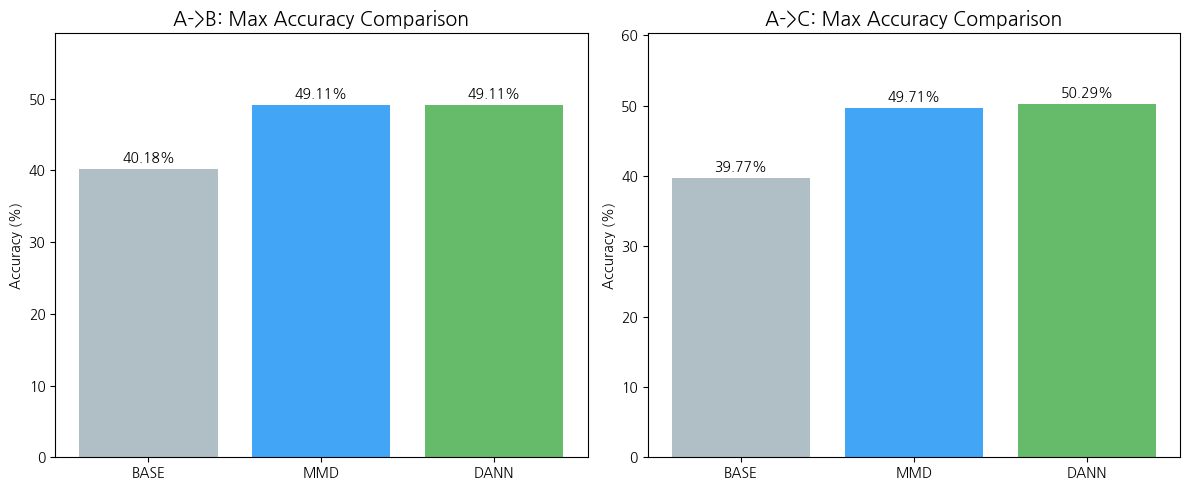

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 1. 데이터 불러오기
df = pd.read_csv('results.csv')

# 2. 각 방법론의 최고 성능(Max Accuracy) 추출
results_ab = {
    'BASE': df['Base(A->B)'].max(),
    'MMD': df['MMD(A->B)'].max(),
    'DANN': df['DANN(A->B)'].max()
}
results_ac = {
    'BASE': df['Base(A->C)'].max(),
    'MMD': df['MMD(A->C)'].max(),
    'DANN': df['DANN(A->C)'].max()
}

# 3. 그래프 그리기 (A->B, A->C)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# A->B 그래프
axes[0].bar(results_ab.keys(), results_ab.values(), color=['#B0BEC5', '#42A5F5', '#66BB6A'])
axes[0].set_title('A->B: Max Accuracy Comparison', fontsize=14)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, max(results_ab.values()) + 10)
for i, v in enumerate(results_ab.values()): # 막대 위에 정확도 숫자 표시
    axes[0].text(i, v + 1, f"{v:.2f}%", ha='center')

# A->C 그래프
axes[1].bar(results_ac.keys(), results_ac.values(), color=['#B0BEC5', '#42A5F5', '#66BB6A'])
axes[1].set_title('A->C: Max Accuracy Comparison', fontsize=14)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, max(results_ac.values()) + 10)
for i, v in enumerate(results_ac.values()): 
    axes[1].text(i, v + 1, f"{v:.2f}%", ha='center')

plt.tight_layout()
plt.savefig('visualizations/comparison_between_domains.png', dpi=300, bbox_inches='tight') # 디렉토리 visualization에 저장
plt.show()

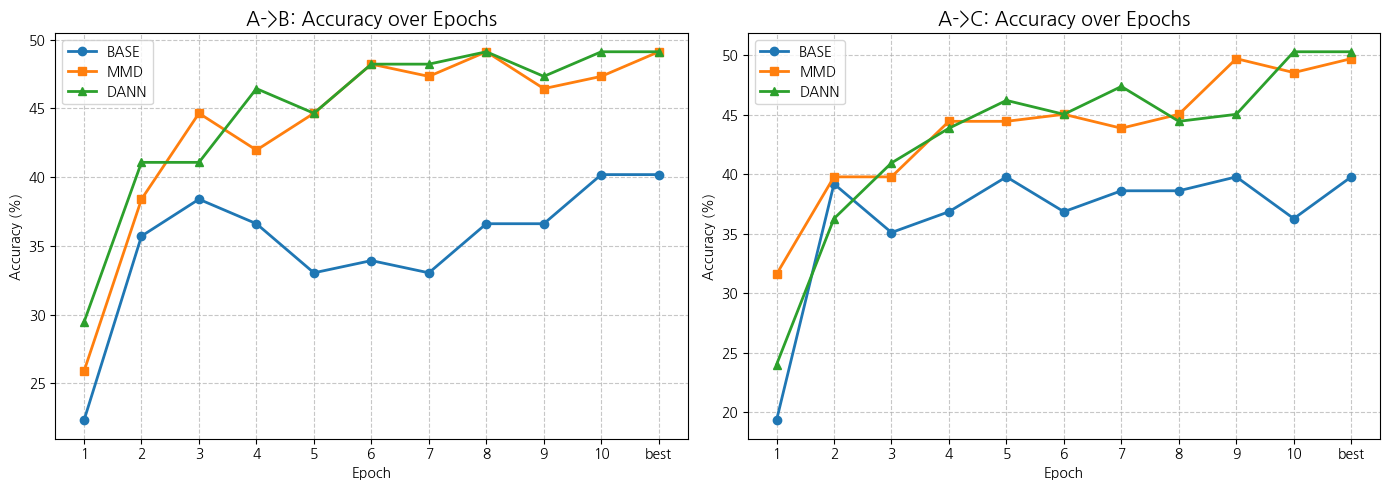

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('results.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A->B 학습 곡선
axes[0].plot(df['epoch'], df['Base(A->B)'], label='BASE', marker='o', linewidth=2)
axes[0].plot(df['epoch'], df['MMD(A->B)'], label='MMD', marker='s', linewidth=2)
axes[0].plot(df['epoch'], df['DANN(A->B)'], label='DANN', marker='^', linewidth=2)
axes[0].set_title('A->B: Accuracy over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# A->C 학습 곡선
axes[1].plot(df['epoch'], df['Base(A->C)'], label='BASE', marker='o', linewidth=2)
axes[1].plot(df['epoch'], df['MMD(A->C)'], label='MMD', marker='s', linewidth=2)
axes[1].plot(df['epoch'], df['DANN(A->C)'], label='DANN', marker='^', linewidth=2)
axes[1].set_title('A->C: Accuracy over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('visualizations/comparison_between_domains(epochs).png', dpi=300)
plt.show()

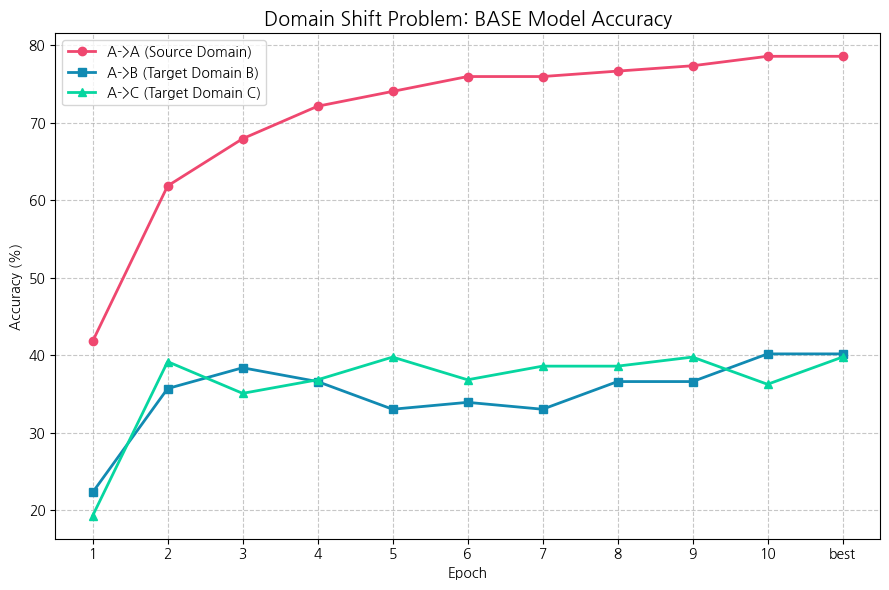

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('results.csv')

# 2. BASE 모델의 세 도메인(A->A, A->B, A->C) 성능 변화 라인 차트 그리기
plt.figure(figsize=(9, 6))

# A->A (학습한 원본 도메인)
plt.plot(df['epoch'], df['Base(A->A)'], label='A->A (Source Domain)', marker='o', linewidth=2, color='#ef476f')
# A->B (새로운 도메인 B)
plt.plot(df['epoch'], df['Base(A->B)'], label='A->B (Target Domain B)', marker='s', linewidth=2, color='#118ab2')
# A->C (새로운 도메인 C)
plt.plot(df['epoch'], df['Base(A->C)'], label='A->C (Target Domain C)', marker='^', linewidth=2, color='#06d6a0')

plt.title('BASE Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('visualizations/base_three_domains_line.png', dpi=300, bbox_inches='tight') # 이미지 파일로 저장
plt.show() # 화면에 출력